XORModel(
  (linear1): Linear(in_features=2, out_features=2, bias=True)
  (activation1): Sigmoid()
  (linear2): Linear(in_features=2, out_features=1, bias=True)
  (activation2): ReLU()
)

Epoch : 1  Train Loss:  0.28455115109682083


/home/mca/anaconda3/envs/dse/lib/python3.12/site-packages/torch/nn/modules/loss.py:608: UserWarning: Using a target size (torch.Size([1])) that is different to the input size (torch.Size([1, 1])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)



Epoch : 1001  Train Loss:  0.25913458690047264

Epoch : 2001  Train Loss:  0.0001244628529093461

Epoch : 3001  Train Loss:  9.543477119677846e-12

Epoch : 4001  Train Loss:  1.595168441781425e-12

Epoch : 5001  Train Loss:  1.595168441781425e-12

Epoch : 6001  Train Loss:  1.595168441781425e-12

Epoch : 7001  Train Loss:  1.595168441781425e-12

Epoch : 8001  Train Loss:  1.63069557856943e-12

Epoch : 9001  Train Loss:  1.63069557856943e-12

Model paramters:

('w', Parameter containing:
tensor([0.8823], device='cuda:0', requires_grad=True))
('b', Parameter containing:
tensor([0.9150], device='cuda:0', requires_grad=True))
('linear1.weight', Parameter containing:
tensor([[-2.6233,  2.5992],
        [-2.3309,  2.3133]], device='cuda:0', requires_grad=True))
('linear1.bias', Parameter containing:
tensor([-1.8279,  1.2729], device='cuda:0', requires_grad=True))
('linear2.weight', Parameter containing:
tensor([[ 2.7392, -2.5743]], device='cuda:0', requires_grad=True))
('linear2.bias', Para

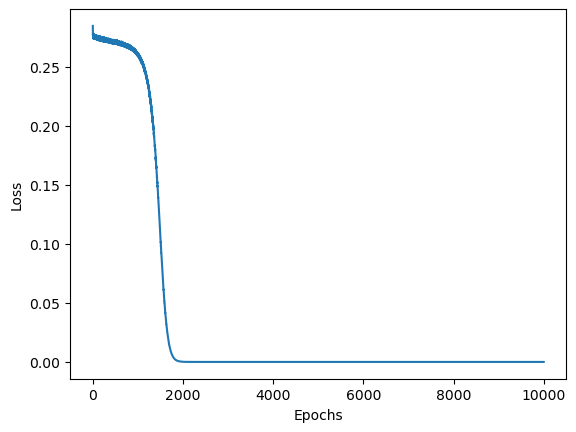

In [ ]:
#Q1)Implement two layer Feed Forward Neural Network for XOR Logic Gate with 
# 2-bit Binary Input using Sigmoid activation. 
# Verify the number of learnable parameters in the model.

import torch
import matplotlib.pyplot as plt
from torch.utils.data import Dataset, DataLoader
import torch.optim as optim
import torch.nn as nn
import numpy as np

loss_list=[]

torch.manual_seed(42)

X=torch.tensor([[0,0],[0,1],[1,0],[1,1]],dtype=torch.float32)
Y=torch.tensor([0,1,1,0],dtype=torch.float32)

class XORModel(nn.Module):
    def __init__(self):
        super(XORModel,self).__init__()
        self.w=torch.nn.Parameter(torch.rand([1]))
        self.b=torch.nn.Parameter(torch.rand([1]))

        self.linear1=nn.Linear(2,2,bias=True)
        self.activation1=nn.Sigmoid()
        self.linear2=nn.Linear(2,1,bias=True)
        self.activation2=nn.ReLU()
    def forward(self,x):
        x=self.linear1(x)
        x=self.activation1(x)
        x=self.linear2(x)
        x=self.activation2(x)
        return x
    
class MyDataset(Dataset):
    def __init__(self,X,Y):
        self.X=X
        self.Y=Y
    def __len__(self):
        return len(self.X)
    def __getitem__(self,idx):
        return self.X[idx].to(device),self.Y[idx].to(device)
    
full_dataset=MyDataset(X,Y)
batch_size=1

train_data_loader=DataLoader(full_dataset,batch_size=batch_size,shuffle=True)

device=torch.device("cuda" if torch.cuda.is_available() else "cpu")

model=XORModel().to(device)
print(model)

loss_fn=nn.MSELoss()
optimizer=optim.SGD(model.parameters(),lr=0.03)

def train_one_epoch(epoch_idx):
    total_loss=0.0
    for i,data in enumerate(train_data_loader):
        inputs, labels=data

        optimizer.zero_grad()
        
        outputs=model(inputs)
        loss=loss_fn(outputs.flatten(), labels)
        loss.backward()

        optimizer.step()
        total_loss+=loss.item()
    return total_loss/(len(train_data_loader)*batch_size)

epochs=10000
for epoch in range(epochs):
    model.train(True)
    avg_loss=train_one_epoch(epoch)
    loss_list.append(avg_loss)
    if (epoch%1000==0):
        print("\nEpoch :",epoch+1," Train Loss: ",avg_loss)

print("\nModel paramters:\n")
for param in model.named_parameters():
    print(param)

input=torch.tensor([0,1],dtype=torch.float32).to(device)
model.eval()
print("Input is: ",input)
print("Predicted Output: ",model(input))

plt.plot(loss_list)
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.show()


In [ ]:
#Q3
import torch

# Linear
w1 = model.linear1.weight.data
b1 = model.linear1.bias.data
# Linear2
w2 = model.linear2.weight.data
b2 = model.linear2.bias.data

def manual_xor(input_x):
    z1 = torch.matmul(input_x, w1.t()) + b1
    a1 = torch.sigmoid(z1)
    
    z2 = torch.matmul(a1, w2.t()) + b2
    a2 = torch.relu(z2)
    
    return a2, a1, z1

test_input = torch.tensor([0.0, 1.0]).to(device)
manual_out, hidden_act, hidden_z = manual_xor(test_input)
model_out = model(test_input)

print(f"Manual Verification for Input {test_input.tolist()}")
print(f"Layer 1 (Linear): {hidden_z.tolist()}")
print(f"Layer 1 (Sigmoid): {hidden_act.tolist()}")
print(f"Manual Final Output (ReLU): {manual_out.item():.4f}")
print(f"Model Final Output: {model_out.item():.4f}")


Manual Verification for Input [0.0, 1.0]
Layer 1 (Linear): [0.7713351249694824, 3.5861761569976807]
Layer 1 (Sigmoid): [0.6838096380233765, 0.9730427265167236]
Manual Final Output (ReLU): 1.0000
Model Final Output: 1.0000
Verification Match: True


Model:
 XORModel(
  (linear1): Linear(in_features=2, out_features=2, bias=True)
  (activation1): ReLU()
  (linear2): Linear(in_features=2, out_features=1, bias=True)
  (activation2): ReLU()
)
Epoch:  1  Loss:  0.25849616527557373
Epoch:  1001  Loss:  1.829647544582258e-13
Epoch:  2001  Loss:  9.059419880941277e-14
Epoch:  3001  Loss:  9.85878045867139e-14
Epoch:  4001  Loss:  9.059419880941277e-14
Epoch:  5001  Loss:  9.059419880941277e-14
Epoch:  6001  Loss:  8.260059303211165e-14
Epoch:  7001  Loss:  9.85878045867139e-14
Epoch:  8001  Loss:  8.260059303211165e-14
Epoch:  9001  Loss:  9.85878045867139e-14

Model Paramters:
('w', Parameter containing:
tensor([0.8823], device='cuda:0', requires_grad=True))
('b', Parameter containing:
tensor([0.9150], device='cuda:0', requires_grad=True))
('linear1.weight', Parameter containing:
tensor([[-1.2175,  1.2175],
        [-0.7691,  0.7691]], device='cuda:0', requires_grad=True))
('linear1.bias', Parameter containing:
tensor([-9.4114e-09,  7.691

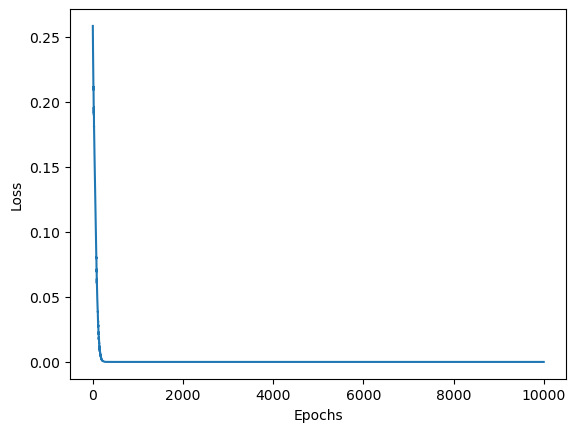

In [36]:
#Q2) Repeat Qn 1 by modifying the activation function to ReLU. 

import torch
import matplotlib.pyplot as plt
from torch.utils.data import Dataset, DataLoader
import torch.nn as nn
import numpy as np

loss_list=[]
torch.manual_seed(42)

X=torch.tensor([[0,0],[0,1],[1,0],[1,1]],dtype=torch.float32)
Y=torch.tensor([0,1,1,0],dtype=torch.float32)

class XORModel(nn.Module):
    def __init__(self):
        super(XORModel,self).__init__()
        self.w=torch.nn.Parameter(torch.rand([1]))
        self.b=torch.nn.Parameter(torch.rand([1]))

        self.linear1=nn.Linear(2,2,bias=True)
        self.activation1=nn.ReLU()
        self.linear2=nn.Linear(2,1,bias=True)
        self.activation2=nn.ReLU()
    def forward(self,x):
        x=self.linear1(x)
        x=self.activation1(x)
        x=self.linear2(x)
        x=self.activation2(x)
        return x

class MyDataset(Dataset):
    def __init__(self,X,Y):
        self.X=X
        self.Y=Y
    def __len__(self):
        return len(self.X)
    def __getitem__(self,idx):
        return self.X[idx].to(device),self.Y[idx].to(device)

full_dataset=MyDataset(X,Y)

batch_size=1

train_data_loader=DataLoader(full_dataset,batch_size=batch_size,shuffle=True)

device=torch.device("cuda" if torch.cuda.is_available() else "cpu")

model=XORModel().to(device)
print("Model:\n",model)

loss_fn=torch.nn.MSELoss()
optimizer=torch.optim.SGD(model.parameters(),lr=0.03)

def train_one_epoch(epoch_idx):
    total_loss=0.0
    for i,data in enumerate(train_data_loader):
        inputs,labels=data

        optimizer.zero_grad()

        outputs=model(inputs)
        loss=loss_fn(outputs.flatten(),labels)
        loss.backward()

        optimizer.step()
        total_loss+=loss.item()

    return total_loss/(len(train_data_loader)*batch_size)

epochs=10000

for epoch in range(epochs):
    model.train(True)
    avg_loss=train_one_epoch(epoch)
    
    loss_list.append(avg_loss)
    if (epoch%1000==0):
        print("Epoch: ",epoch+1," Loss: ",avg_loss)

print("\nModel Paramters:")
for param in model.named_parameters():
    print(param)

input=torch.tensor([0,1],dtype=torch.float32).to(device)
model.eval()
print("Input: ",input)
print("Output Predcition: ",model(input))

plt.plot(loss_list)
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.show()

Total Trainable Parameters:  235146
Epoch [1/5], Loss: 0.2072
Epoch [2/5], Loss: 0.1016
Epoch [3/5], Loss: 0.0784
Epoch [4/5], Loss: 0.0658
Epoch [5/5], Loss: 0.0544


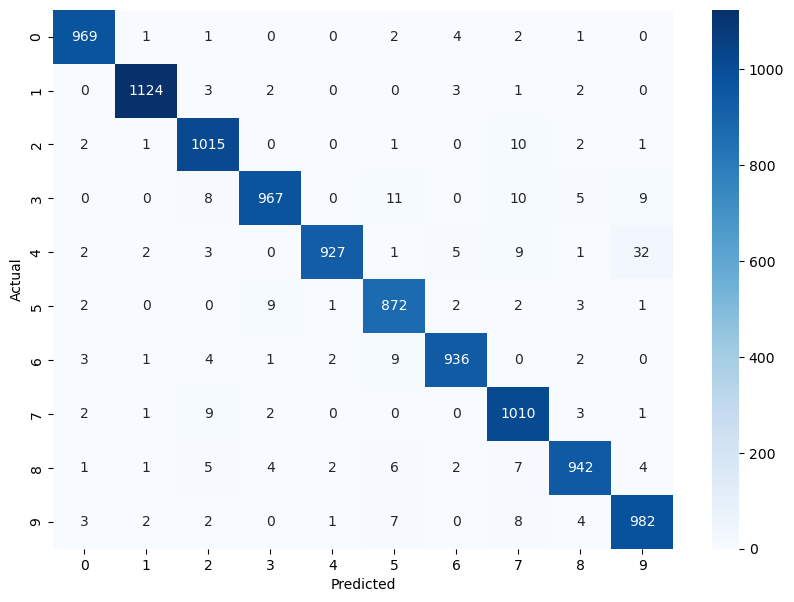

In [ ]:
#Q4)Implement Feed Forward Neural Network with two hidden layers for classifying
#  handwritten digits using MNIST dataset. Display the classification accuracy 
# in the form of a Confusion matrix. Verify the number of learnable parameters in 
# the model.                  

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
import numpy as np
from torchvision import datasets
from torchvision.transforms import ToTensor
from sklearn.metrics import confusion_matrix
import seaborn as sns


input_size=784
hidden_layer1=256
hidden_layer2=128
num_classes=10
learning_rate=0.001
batch_size=4
epochs=5

train_dataset=datasets.MNIST(root='./data', train=True, transform=ToTensor(), download=True)
test_dataset=datasets.MNIST(root='./data', train=False, transform=ToTensor(), download=True)


train_data_loader=DataLoader(train_dataset,batch_size=batch_size,shuffle=True)
test_data_loader=DataLoader(test_dataset,batch_size=batch_size,shuffle=False)

class MNISTClassifier(nn.Module):
    def __init__(self,input_size,h1,h2,num_classes):
        super().__init__()
        self.linear1=nn.Linear(input_size,h1)
        self.relu1=nn.ReLU()
        self.linear2=nn.Linear(h1,h2)
        self.relu2=nn.ReLU()
        self.linear3=nn.Linear(h2,num_classes)
    def forward(self,x):
        x=x.view(-1,784)
        x=self.relu1(self.linear1(x))
        x=self.relu2(self.linear2(x))
        return self.linear3(x)

model=MNISTClassifier(input_size,hidden_layer1,hidden_layer2,num_classes)

'''
total_params=0
for name,param in model.named_parameters():
    #print(param)
    params=param.numel()
    total_params+=params'''
total_params = sum(p.numel() for p in model.parameters())
print("Total Trainable Parameters: ",total_params)

criterion=nn.CrossEntropyLoss()
optimizer=optim.Adam(model.parameters(),lr=learning_rate)

model.train()

for epoch in range(epochs):
    running_loss = 0.0
    for images, labels in train_data_loader:
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()

    print(f"Epoch [{epoch+1}/{epochs}], Loss: {running_loss/len(train_data_loader):.4f}")


model.eval()
all_preds,all_labels=[],[]
with torch.no_grad():
    for images,labels in test_data_loader:
        outputs=model(images)
        _,predicted=torch.max(outputs,1)
        all_preds.extend(predicted.numpy())
        all_labels.extend(labels.numpy())

cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(10,7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()
